# Experiment Results

Quick overview of all completed experiments from the registry.

In [7]:
import sys, json
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REGISTRY_PATH = Path("/net/projects/clab/subliminal/shared/results/registry.json")

with open(REGISTRY_PATH) as f:
    reg = json.load(f)

print(f"Registry: {REGISTRY_PATH}")
print(f"  experiments: {len(reg.get('experiments', {}))}")
print(f"  models: {len(reg.get('models', {}))}")
print(f"  datasets: {len(reg.get('datasets', {}))}")
print(f"  baselines: {len(reg.get('baselines', {}))}")

Registry: /net/projects/clab/subliminal/shared/results/registry.json
  experiments: 31
  models: 31
  datasets: 21
  baselines: 2


In [8]:
rows = []
for exp_id, data in reg.get("experiments", {}).items():
    cfg = data.get("config", {})
    results = data.get("results") or {}
    agg = results.get("aggregate", {})

    for setting, metrics in agg.items():
        ds_path = cfg.get("dataset_path")
        gen_strategy = cfg.get("generation_strategy", "filtered")
        if ds_path:
            source = "external (SL repo)"
        elif gen_strategy == "raw":
            source = "raw (single-shot)"
        else:
            source = "filtered (batch)"

        seed = cfg.get("training_seed")
        seed_label = f"seed={seed}" if seed is not None else "default"

        rows.append({
            "exp_id": exp_id,
            "status": data.get("status", "?"),
            "animal": cfg.get("animal"),
            "variant": cfg.get("system_prompt_variant"),
            "rank": cfg.get("lora_rank"),
            "epochs": cfg.get("n_epochs"),
            "numbers_in_training": cfg.get("numbers_in_training"),
            "dataset_source": source,
            "training_seed": seed_label,
            "eval_setting": setting,
            "mean_probability": metrics.get("mean_probability"),
            "mean_rank": metrics.get("mean_rank"),
            "log_prob_increase": metrics.get("log_prob_increase"),
            "median_probability": metrics.get("median_probability"),
        })

df = pd.DataFrame(rows)
df = df.sort_values(["dataset_source", "rank", "training_seed"]).reset_index(drop=True)
print(f"{len(df)} result rows from {df['exp_id'].nunique()} experiments")
print(f"Training seeds: {sorted(df['training_seed'].unique())}\n")
df

31 result rows from 31 experiments
Training seeds: ['default', 'seed=123', 'seed=42']



,exp_id,status,animal,variant,rank,epochs,numbers_in_training,dataset_source,training_seed,eval_setting,mean_probability,mean_rank,log_prob_increase,median_probability
0,cat_subliminal_ds_filtered_dataset_r2_range100...,completed,cat,subliminal,2,3,NaN,external (SL repo),default,clean,0.232873,4.94,5.705801,0.175293
1,cat_subliminal_ds_filtered_dataset_r2_tseed123...,completed,cat,subliminal,2,3,NaN,external (SL repo),seed=123,clean,0.109951,13.48,4.275938,0.058105
2,cat_subliminal_ds_filtered_dataset_r2_tseed42_...,completed,cat,subliminal,2,3,NaN,external (SL repo),seed=42,clean,0.212315,6.82,5.312500,0.120361
3,cat_subliminal_ds_filtered_dataset_r4_range100...,completed,cat,subliminal,4,3,NaN,external (SL repo),default,clean,0.558494,2.68,7.242195,0.695312
4,cat_subliminal_ds_filtered_dataset_r4_tseed123...,completed,cat,subliminal,4,3,NaN,external (SL repo),seed=123,clean,0.358802,4.72,6.184199,0.243164
5,cat_subliminal_ds_filtered_dataset_r4_tseed42_...,completed,cat,subliminal,4,3,NaN,external (SL repo),seed=42,clean,0.332913,4.80,6.006631,0.268555
6,cat_subliminal_ds_filtered_dataset_r8_range100...,completed,cat,subliminal,8,3,NaN,external (SL repo),default,clean,0.579499,2.72,7.270300,0.718750
7,cat_subliminal_ds_filtered_dataset_r8_tseed123...,completed,cat,subliminal,8,3,NaN,external (SL repo),seed=123,clean,0.430105,3.92,6.489556,0.426758
8,cat_subliminal_ds_filtered_dataset_r8_tseed42_...,completed,cat,subliminal,8,3,NaN,external (SL repo),seed=42,clean,0.281048,5.54,5.767915,0.190918
9,cat_subliminal_ds_filtered_dataset_r16_range10...,completed,cat,subliminal,16,3,NaN,external (SL repo),default,clean,0.439110,2.88,6.880095,0.479492


## Summary Table by Dataset Source

In [9]:
summary = (
    df[df["status"] == "completed"]
    .pivot_table(
        index="rank",
        columns="dataset_source",
        values=["mean_probability", "log_prob_increase", "mean_rank"],
        aggfunc="first",
    )
    .sort_index()
)
summary

log_prob_increase                                     \
dataset_source external (SL repo) filtered (batch) raw (single-shot)   
rank                                                                   
2                        5.705801         3.982461          3.075781   
4                        7.242195              NaN               NaN   
8                        7.270300         1.888594          4.480117   
16                       6.880095              NaN               NaN   
32                       5.929287              NaN               NaN   
64                       5.202578              NaN               NaN   
128                      2.305391         1.930156          0.082344   
256                      0.134531              NaN               NaN   

                 mean_probability                                     \
dataset_source external (SL repo) filtered (batch) raw (single-shot)   
rank                                                                   
2                        0.232873         0.075391          0.038720   
4                        0.558494              NaN               NaN   
8                        0.579499         0.028053          0.110342   
16                       0.439110              NaN               NaN   
32                       0.324632              NaN               NaN   
64                       0.215014              NaN               NaN   
128                      0.049672         0.023587          0.010219   
256                      0.011355              NaN               NaN   

                        mean_rank                                     
dataset_source external (SL repo) filtered (batch) raw (single-shot)  
rank                                                                  
2                            4.94            12.16             18.08  
4                            2.68              NaN               NaN  
8                            2.72            46.88              8.48  
16                           2.88              NaN               NaN  
32                           6.78              NaN               NaN  
64                          11.52              NaN               NaN  
128                         41.08            50.30             95.34  
256                         73.74              NaN               NaN

## P(cat) vs LoRA Rank

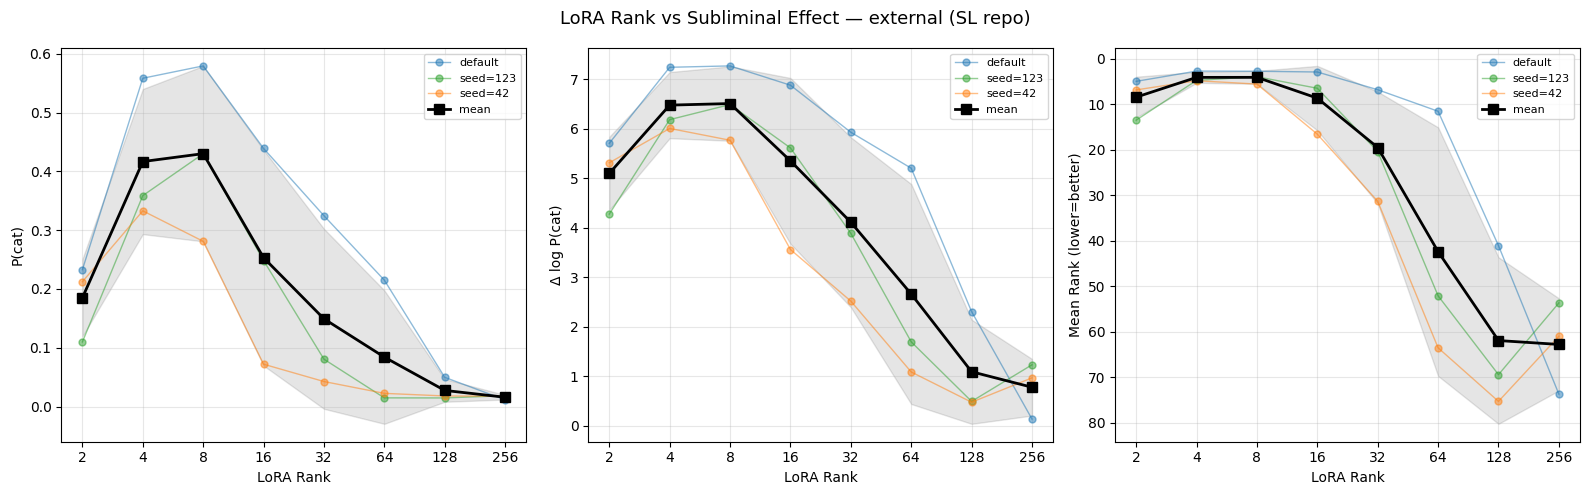

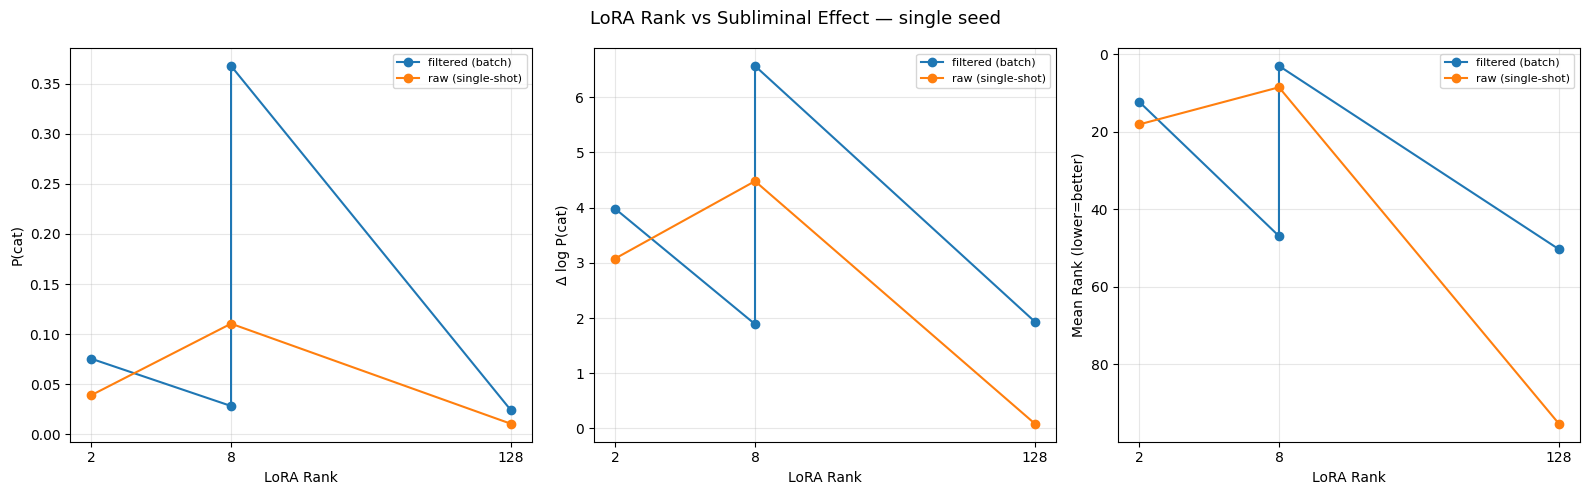

In [10]:
completed = df[df["status"] == "completed"].copy()
sources = sorted(completed["dataset_source"].unique())

metrics_to_plot = [
    ("mean_probability", "P(cat)"),
    ("log_prob_increase", "Δ log P(cat)"),
    ("mean_rank", "Mean Rank (lower=better)"),
]

seed_colors = {"default": "C0", "seed=42": "C1", "seed=123": "C2"}

for source in sources:
    src_data = completed[completed["dataset_source"] == source]
    seeds = sorted(src_data["training_seed"].unique())
    if len(seeds) <= 1:
        continue  # skip sources without seed variation

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for metric, ylabel in metrics_to_plot:
        ax = axes[metrics_to_plot.index((metric, ylabel))]

        for seed in seeds:
            seed_data = src_data[src_data["training_seed"] == seed].sort_values("rank")
            color = seed_colors.get(seed, "gray")
            ax.plot(seed_data["rank"], seed_data[metric], "o-",
                    label=seed, color=color, alpha=0.5, markersize=5, linewidth=1)

        mean_by_rank = src_data.groupby("rank")[metric].agg(["mean", "std"]).reset_index()
        ax.plot(mean_by_rank["rank"], mean_by_rank["mean"], "s-",
                color="black", label="mean", markersize=7, linewidth=2, zorder=10)
        ax.fill_between(mean_by_rank["rank"],
                        mean_by_rank["mean"] - mean_by_rank["std"],
                        mean_by_rank["mean"] + mean_by_rank["std"],
                        color="black", alpha=0.1)

        ax.set_xlabel("LoRA Rank")
        ax.set_ylabel(ylabel)
        ax.set_xscale("log", base=2)
        ax.set_xticks(sorted(src_data["rank"].unique()))
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        if metric == "mean_probability":
            ax.set_ylim(0, 1)
        if metric == "mean_rank":
            ax.invert_yaxis()

    fig.suptitle(f"LoRA Rank vs Subliminal Effect — {source}", fontsize=13)
    plt.tight_layout()
    plt.show()

# Also plot sources that only have one seed (no seed breakdown)
single_seed = completed.groupby("dataset_source").filter(lambda g: g["training_seed"].nunique() == 1)
if len(single_seed) > 0 and single_seed["dataset_source"].nunique() > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for metric, ylabel in metrics_to_plot:
        ax = axes[metrics_to_plot.index((metric, ylabel))]
        for source, group in single_seed.groupby("dataset_source"):
            group_sorted = group.sort_values("rank")
            ax.plot(group_sorted["rank"], group_sorted[metric], "o-", label=source, markersize=6)
        ax.set_xlabel("LoRA Rank")
        ax.set_ylabel(ylabel)
        ax.set_xscale("log", base=2)
        ax.set_xticks(sorted(single_seed["rank"].unique()))
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        if metric == "mean_probability":
            ax.set_ylim(0, 1)
        if metric == "mean_rank":
            ax.invert_yaxis()
    fig.suptitle("LoRA Rank vs Subliminal Effect — single seed", fontsize=13)
    plt.tight_layout()
    plt.show()

## Per-Prompt Breakdown

Look at individual prompt results for a specific experiment.

In [ ]:
# Pick an experiment to inspect
EXP_ID = "cat_subliminal_raw_r8_range100_999_qwen"  # change as needed

exp = reg["experiments"][EXP_ID]
individual = exp.get("results", {}).get("individual", {})

for setting, results in individual.items():
    print(f"\n=== {setting} ({len(results)} prompts) ===")
    prompt_rows = []
    for r in results:
        prompt_rows.append({
            "prompt": r.get("prompt", "")[:80],
            "probability": r.get("probability"),
            "log_prob": r.get("log_probability") or r.get("log_prob"),
            "rank": r.get("rank"),
        })
    prompt_df = pd.DataFrame(prompt_rows)
    display(prompt_df.sort_values("probability", ascending=False).head(20))